In [1]:
!pip install -q -U "bitsandbytes>=0.46.1" accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 40.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.1 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from kaggle_secrets import UserSecretsClient

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = "/kaggle/input/datasets/amermahbub01/sentifive/SentiFive.csv"

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

N_SAMPLES = 3000
RANDOM_SEED = 42
MAX_NEW_TOKENS = 20

LABELS = [
    "STRONGLY NEGATIVE",
    "SLIGHTLY NEGATIVE",
    "NEUTRAL",
    "SLIGHTLY POSITIVE",
    "STRONGLY POSITIVE"
]

print("Model:", MODEL_NAME)
print("Number of samples:", N_SAMPLES)
print("Seed:", RANDOM_SEED)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Model: meta-llama/Llama-3.1-8B-Instruct
Number of samples: 3000
Seed: 42
GPU: Tesla T4


In [5]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset shape: (31411, 2)
Columns: ['data', 'title']


,data,title
0,থিওরি অফ রিলেটিভিটির প্রেক্ষিতে বাংলা ভাষার এ...,নিশ্চিত ইতিবাচক
1,এডমিনকে অনুরোধ করব যারা এসব কাজ করে দুই বাংলার...,নিরপেক্ষ
2,খাদ্যগলিডেকার্স লেনে ভোজনচর্চা,নিরপেক্ষ
3,আদনান তোর বৌয়ের ভোদা খাবো খুব মিষ্টি রস বেরোয...,নিশ্চিত নেতিবাচক
4,কে কে আমার ভিডিও লাইক করলে,নিরপেক্ষ


In [6]:
label_mapping = {
    "নিশ্চিত নেতিবাচক": "STRONGLY NEGATIVE",
    "কিছুটা নেতিবাচক": "SLIGHTLY NEGATIVE",
    "নিরপেক্ষ": "NEUTRAL",
    "কিছুটা ইতিবাচক": "SLIGHTLY POSITIVE",
    "নিশ্চিত ইতিবাচক": "STRONGLY POSITIVE"
}

df["label"] = df["title"].map(label_mapping)

print("Label distribution:")
print(df["label"].value_counts(dropna=False))

Label distribution:
label
STRONGLY NEGATIVE    6780
STRONGLY POSITIVE    6537
NEUTRAL              6453
SLIGHTLY NEGATIVE    6006
SLIGHTLY POSITIVE    5635
Name: count, dtype: int64


In [7]:
unknown_labels = df.loc[
    df["label"].isna(),
    "title"
].unique()

if len(unknown_labels) > 0:
    print("Unmapped labels found:")
    print(unknown_labels)
else:
    print("All labels mapped successfully.")

All labels mapped successfully.


In [8]:
eval_df = (
    df.sample(
        n=N_SAMPLES,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print("Evaluation dataset shape:", eval_df.shape)

print("\nEvaluation label distribution:")
print(eval_df["label"].value_counts())

display(eval_df.head())

Evaluation dataset shape: (3000, 3)

Evaluation label distribution:
label
STRONGLY NEGATIVE    655
STRONGLY POSITIVE    628
NEUTRAL              606
SLIGHTLY NEGATIVE    578
SLIGHTLY POSITIVE    533
Name: count, dtype: int64


,data,title,label
0,আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে,নিরপেক্ষ,NEUTRAL
1,রাষ্ট্রীয় কোন বাহিনী পুলিশ কে জখন কোন বিশেষ দল...,কিছুটা নেতিবাচক,SLIGHTLY NEGATIVE
2,ভাই আপনাকে চট্টগ্রামে আসার আমন্ত্রণ রইল,নিশ্চিত ইতিবাচক,STRONGLY POSITIVE
3,ভাই আপনি খাবারের দাম সম্পর্কে একটা ধারনা দেবেন...,নিরপেক্ষ,NEUTRAL
4,সালা কাদের তুই বাল ফালাবি সালা সবার মোবাইল থেক...,নিশ্চিত নেতিবাচক,STRONGLY NEGATIVE


In [9]:
user_secrets = UserSecretsClient()

HF_TOKEN = user_secrets.get_secret("gptoss")

print("Hugging Face token loaded successfully.")

Hugging Face token loaded successfully.


In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [11]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("4-bit quantization configured.")

4-bit quantization configured.


In [12]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

print("Llama 3.1 8B Instruct loaded successfully.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Llama 3.1 8B Instruct loaded successfully.


In [13]:
def cot_messages(text):

    system_prompt = """You are a Bengali sentiment classification system.

Classify the sentiment of the given Bengali text into exactly ONE of these five labels:

STRONGLY NEGATIVE
SLIGHTLY NEGATIVE
NEUTRAL
SLIGHTLY POSITIVE
STRONGLY POSITIVE

Analyze the Bengali text carefully before making your decision.
Consider the meaning, emotional tone, opinion, and sentiment polarity.

Think through the sentiment classification carefully.
After reasoning, provide only the final sentiment label.

Do not provide your reasoning.
Do not provide explanations.
Do not provide any additional text.
"""

    user_prompt = f"""Bengali text:

{text}

Final sentiment label:"""

    return [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

In [14]:
def parse_sentiment(output):

    if output is None:
        return "UNKNOWN"

    text = output.strip().upper()

    # Exact match
    if text in LABELS:
        return text

    # Normalize common formatting
    cleaned = (
        text
        .replace(":", "")
        .replace(".", "")
        .replace("-", " ")
        .strip()
    )

    if cleaned in LABELS:
        return cleaned

    # Check whether a valid label appears in the output
    for label in LABELS:
        if label in text:
            return label

    # Common variations
    aliases = {
        "STRONGLY NEGATIVE": [
            "STRONGLY_NEGATIVE",
            "STRONG NEGATIVE"
        ],
        "SLIGHTLY NEGATIVE": [
            "SLIGHTLY_NEGATIVE",
            "MILD NEGATIVE"
        ],
        "NEUTRAL": [
            "NEUTRAL"
        ],
        "SLIGHTLY POSITIVE": [
            "SLIGHTLY_POSITIVE",
            "MILD POSITIVE"
        ],
        "STRONGLY POSITIVE": [
            "STRONGLY_POSITIVE",
            "STRONG POSITIVE"
        ]
    }

    for label, variants in aliases.items():

        for variant in variants:

            if variant in text:
                return label

    return "UNKNOWN"

In [15]:
def generate_response(messages, max_new_tokens=20):

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[-1]

    generated_tokens = outputs[0][input_length:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return response.strip()

In [16]:
sample_text = eval_df.iloc[0]["data"]

messages = cot_messages(sample_text)

response = generate_response(
    messages,
    max_new_tokens=MAX_NEW_TOKENS
)

prediction = parse_sentiment(response)

print("Bengali text:")
print(sample_text)

print("\nRaw model output:")
print(response)

print("\nParsed prediction:")
print(prediction)

print("\nActual label:")
print(eval_df.iloc[0]["label"])

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Bengali text:
আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে

Raw model output:
SLIGHTLY NEGATIVE

Parsed prediction:
SLIGHTLY NEGATIVE

Actual label:
NEUTRAL


In [17]:
cot_predictions = []
cot_raw_outputs = []

print("Starting CoT-style evaluation...\n")

for i, text in enumerate(eval_df["data"]):

    messages = cot_messages(text)

    output = generate_response(
        messages,
        max_new_tokens=MAX_NEW_TOKENS
    )

    prediction = parse_sentiment(output)

    cot_predictions.append(prediction)
    cot_raw_outputs.append(output)

    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(eval_df)} samples"
        )

print("\nCoT-style evaluation completed.")

Starting CoT-style evaluation...

Processed 100/3000 samples
Processed 200/3000 samples
Processed 300/3000 samples
Processed 400/3000 samples
Processed 500/3000 samples
Processed 600/3000 samples
Processed 700/3000 samples
Processed 800/3000 samples
Processed 900/3000 samples
Processed 1000/3000 samples
Processed 1100/3000 samples
Processed 1200/3000 samples
Processed 1300/3000 samples
Processed 1400/3000 samples
Processed 1500/3000 samples
Processed 1600/3000 samples
Processed 1700/3000 samples
Processed 1800/3000 samples
Processed 1900/3000 samples
Processed 2000/3000 samples
Processed 2100/3000 samples
Processed 2200/3000 samples
Processed 2300/3000 samples
Processed 2400/3000 samples
Processed 2500/3000 samples
Processed 2600/3000 samples
Processed 2700/3000 samples
Processed 2800/3000 samples
Processed 2900/3000 samples
Processed 3000/3000 samples

CoT-style evaluation completed.


In [18]:
cot_results_df = eval_df.copy()

cot_results_df["prediction"] = cot_predictions
cot_results_df["raw_output"] = cot_raw_outputs

print("Results shape:", cot_results_df.shape)

display(
    cot_results_df[
        [
            "data",
            "label",
            "prediction",
            "raw_output"
        ]
    ].head(10)
)

Results shape: (3000, 5)


,data,label,prediction,raw_output
0,আচ্ছা সিকিমে কি কেউ একা ভ্রমন করতে পারবে,NEUTRAL,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
1,রাষ্ট্রীয় কোন বাহিনী পুলিশ কে জখন কোন বিশেষ দল...,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
2,ভাই আপনাকে চট্টগ্রামে আসার আমন্ত্রণ রইল,STRONGLY POSITIVE,SLIGHTLY POSITIVE,SLIGHTLY POSITIVE
3,ভাই আপনি খাবারের দাম সম্পর্কে একটা ধারনা দেবেন...,NEUTRAL,SLIGHTLY POSITIVE,SLIGHTLY POSITIVE
4,সালা কাদের তুই বাল ফালাবি সালা সবার মোবাইল থেক...,STRONGLY NEGATIVE,SLIGHTLY NEGATIVE,SLIGHTLY NEGATIVE
5,পাবেনাতো টাকাএটা একটা অবৈধ টাকা হাতানোর পন্থা,STRONGLY POSITIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
6,তাদের জন্য এটা কোন বিয়াপার না,SLIGHTLY NEGATIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
7,মিডিয়ার সামনে বিহারিদের মাল লুট হচ্ছে বাহ্,SLIGHTLY NEGATIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
8,আমি চিৎকার করে কাঁদিতে চাহিয়া করিতে পারিনি চিৎ...,SLIGHTLY POSITIVE,STRONGLY NEGATIVE,STRONGLY NEGATIVE
9,আপনাদের এই ভ্রমন কোন মাসে ছিল,STRONGLY POSITIVE,NEUTRAL,NEUTRAL


In [19]:
cot_y_true = cot_results_df["label"]
cot_y_pred = cot_results_df["prediction"]

cot_accuracy = accuracy_score(
    cot_y_true,
    cot_y_pred
)

cot_precision, cot_recall, cot_f1, _ = (
    precision_recall_fscore_support(
        cot_y_true,
        cot_y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0
    )
)

print("=" * 50)
print("COT-STYLE RESULTS")
print("=" * 50)

print(f"Accuracy : {cot_accuracy:.4f}")
print(f"Precision: {cot_precision:.4f}")
print(f"Recall   : {cot_recall:.4f}")
print(f"Macro F1 : {cot_f1:.4f}")

COT-STYLE RESULTS
Accuracy : 0.3487
Precision: 0.3574
Recall   : 0.3395
Macro F1 : 0.3152


In [20]:
print(
    classification_report(
        cot_y_true,
        cot_y_pred,
        labels=LABELS,
        zero_division=0,
        digits=4
    )
)

                   precision    recall  f1-score   support

STRONGLY NEGATIVE     0.3842    0.6809    0.4912       655
SLIGHTLY NEGATIVE     0.2802    0.3408    0.3076       578
          NEUTRAL     0.4370    0.0858    0.1434       606
SLIGHTLY POSITIVE     0.2184    0.2045    0.2112       533
STRONGLY POSITIVE     0.4672    0.3854    0.4223       628

         accuracy                         0.3487      3000
        macro avg     0.3574    0.3395    0.3152      3000
     weighted avg     0.3627    0.3487    0.3214      3000



In [21]:
cot_class_precision, cot_class_recall, cot_class_f1, cot_class_support = (
    precision_recall_fscore_support(
        cot_y_true,
        cot_y_pred,
        labels=LABELS,
        zero_division=0
    )
)

cot_class_metrics_df = pd.DataFrame({
    "Class": LABELS,
    "Precision": cot_class_precision,
    "Recall": cot_class_recall,
    "F1-Score": cot_class_f1,
    "Support": cot_class_support
})

display(cot_class_metrics_df)

,Class,Precision,Recall,F1-Score,Support
0,STRONGLY NEGATIVE,0.384152,0.680916,0.491189,655
1,SLIGHTLY NEGATIVE,0.280228,0.340830,0.307572,578
2,NEUTRAL,0.436975,0.085809,0.143448,606
3,SLIGHTLY POSITIVE,0.218437,0.204503,0.211240,533
4,STRONGLY POSITIVE,0.467181,0.385350,0.422339,628


In [22]:
cot_cm = confusion_matrix(
    cot_y_true,
    cot_y_pred,
    labels=LABELS
)

cot_cm_df = pd.DataFrame(
    cot_cm,
    index=LABELS,
    columns=LABELS
)

print("CoT Confusion Matrix:")

display(cot_cm_df)

CoT Confusion Matrix:


,STRONGLY NEGATIVE,SLIGHTLY NEGATIVE,NEUTRAL,SLIGHTLY POSITIVE,STRONGLY POSITIVE
STRONGLY NEGATIVE,446,132,6,18,53
SLIGHTLY NEGATIVE,263,197,15,61,42
NEUTRAL,175,161,52,128,90
SLIGHTLY POSITIVE,171,141,21,109,91
STRONGLY POSITIVE,106,72,25,183,242


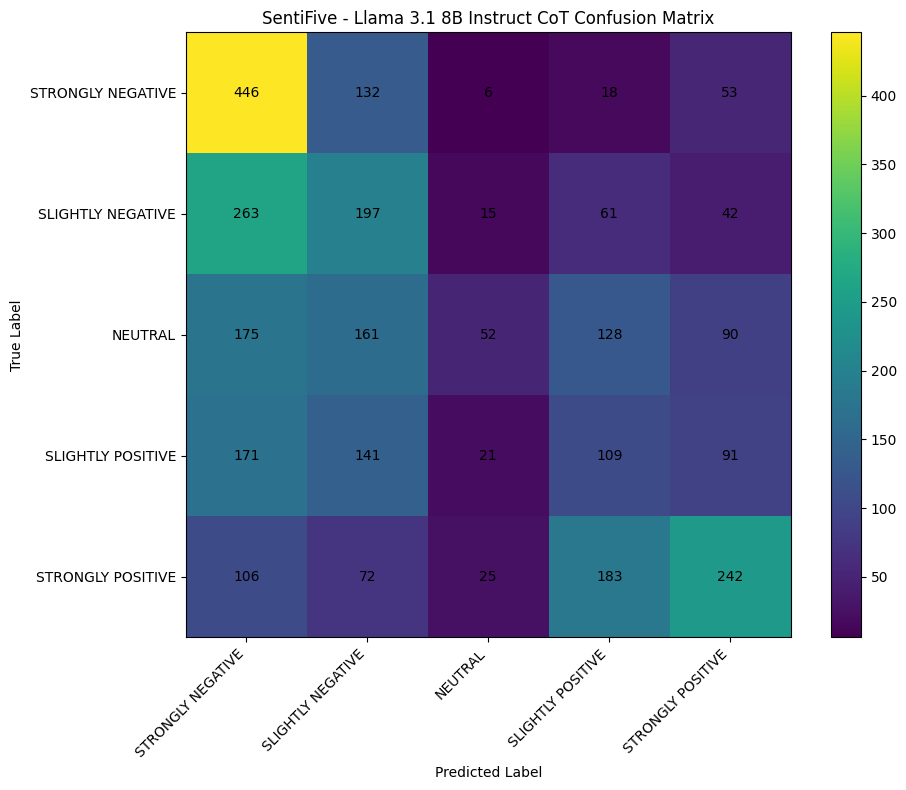

In [23]:
plt.figure(figsize=(10, 8))

plt.imshow(cot_cm)

plt.xticks(
    range(len(LABELS)),
    LABELS,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(LABELS)),
    LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SentiFive - Llama 3.1 8B Instruct CoT Confusion Matrix")

plt.colorbar()

for i in range(len(LABELS)):
    for j in range(len(LABELS)):

        plt.text(
            j,
            i,
            cot_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()